# K-Means Exploration

This script uses the unified_dataset.csv and run a K-means clustering algorithm on it. It uses a subset of the data and scales it via standard scaling. Then it provdes an overview of the K-means algorithm that has the most optimal number of k clusters using the Calinski-Harabasz Score, elbow method, and the silhouette score. It also provides the top features that differentiate clusters. 

Nulls are replaced with -1. The test data is 40% of the original data.

In [1]:
!pip install --upgrade scikit-learn

In [2]:
!pip install kneed

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

In [4]:
data = pd.read_csv("/dsa/groups/casestudycf25/team02/unified_dataset.csv")

In [5]:
# Remove NAs
%matplotlib inline

subset=data.iloc[:, 0:len(data.columns)].copy()

display(subset[subset.isna().any(axis=1)])

,npi,year,target,avg_suplr_sbmtd_chrg_mean,avg_suplr_mdcr_alowd_amt_mean,avg_suplr_mdcr_pymt_amt_mean,avg_suplr_mdcr_stdzd_amt_mean,avg_suplr_sbmtd_chrg_sum,avg_suplr_mdcr_alowd_amt_sum,avg_suplr_mdcr_pymt_amt_sum,...,physician_covered_recipient,year_leie,excltype,num_exclusions_alltime,num_exclusion_types_alltime,fraud_flag,Rfrg_NPI,specialty_type,specialty_lvl1,specialty
0,1003000126,2021,0,129.776563,41.940392,31.813932,34.260562,519.106250,167.761567,127.255730,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
1,1003000126,2022,0,209.273634,54.750832,41.764741,52.602407,418.547268,109.501664,83.529481,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
2,1003000126,2023,0,152.346111,48.740210,32.699442,42.116461,457.038333,146.220631,98.098326,...,NaN,NaN,NaN,NaN,NaN,0,1003000126,Medical Doctor,Allopathic & Osteopathic Physicians,Hospitalist
3,1003000480,2021,0,272.003846,80.513846,64.407692,84.701538,272.003846,80.513846,64.407692,...,0.0,NaN,NaN,NaN,NaN,0,1003000480,Medical Doctor,Allopathic & Osteopathic Physicians,General Surgery
4,1003000522,2021,0,133.101129,22.805968,18.243952,19.471129,266.202258,45.611935,36.487903,...,NaN,NaN,NaN,NaN,NaN,0,1003000522,Doctor of Osteopathy,Allopathic & Osteopathic Physicians,Family Practice
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
873533,1992999122,2023,0,131.440754,45.271515,34.787840,36.480178,1445.848292,497.986665,382.666242,...,0.0,NaN,NaN,NaN,NaN,0,1992999122,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
873534,1992999551,2021,0,196.827930,33.849452,25.531641,32.578168,1574.623440,270.795620,204.253124,...,0.0,NaN,NaN,NaN,NaN,0,1992999551,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
873535,1992999551,2022,0,66.296193,23.048309,17.713123,21.564191,397.777161,138.289853,106.278738,...,NaN,NaN,NaN,NaN,NaN,0,1992999551,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine
873536,1992999551,2023,0,162.403127,62.296425,46.640118,54.865182,1461.628145,560.667821,419.761064,...,0.0,NaN,NaN,NaN,NaN,0,1992999551,Medical Doctor,Allopathic & Osteopathic Physicians,Internal Medicine


### Prep the Data

In [6]:
# Remove all columns whose name contains "date" (case-insensitive)
cols_to_drop = [col for col in subset.columns if 'date' in col.lower()]
subset = subset.drop(columns=cols_to_drop)

In [7]:
subset.dropna(subset = ["n_records"] , inplace = True)

In [8]:
subset.shape

(241269, 167)

In [9]:
subset["num_exclusions_alltime"] = (
      subset["num_exclusions_alltime"]
      .fillna(-1)       # turn NaN into 0
      .astype('int8')
)

In [10]:
subset["num_exclusion_types_alltime"] = (
      subset["num_exclusion_types_alltime"]
      .fillna(-1)       # turn NaN into 0
      .astype('int8')
)

In [11]:
subset.drop(columns = ["Rfrg_NPI", "npi", "covered_recipient_npi", "target", "year_leie"], inplace = True)

In [12]:
drop_cols = [c for c in subset.columns if c.endswith("_median") or c.endswith("_min") or c.endswith("_max")]  

# Drop those columns from the dataframe;
subset = subset.drop(columns=drop_cols)  

In [13]:
# subset.dropna(inplace = True)

In [14]:
subset.shape

(241269, 138)

In [15]:
subset["excltype"].unique()

array([nan, '1128a1', '1128a2', '1128a3', '1128b7'], dtype=object)

In [16]:
########################
# Mapping Text columns to numbers
#############################
excltype_mapping = {'1128a1': 1, '1128a2': 2, '1128a3': 3,'1128b7':7}

In [17]:
subset["excltype"] = (
      subset["excltype"]
      .map(excltype_mapping)     # map Yes/No
      .fillna(0)       # turn NaN into 0
      .astype('int8')
)

In [18]:
# Calculate NaN percentage per column
nan_percent = subset.isna().mean() * 100  # or df.isnull().mean() * 100

# Filter to only columns with NaN % > 0
nan_percent = nan_percent[nan_percent > 0]

# Sort (optional)
nan_percent = nan_percent.sort_values(ascending=False)

print(nan_percent)

avg_suplr_sbmtd_chrg_std        21.974642
avg_suplr_mdcr_alowd_amt_std    21.974642
avg_suplr_mdcr_pymt_amt_std     21.974642
avg_suplr_mdcr_stdzd_amt_std    21.974642
tot_suplrs_std                  21.974642
tot_suplr_benes_std             21.974642
tot_suplr_clms_std              21.974642
tot_suplr_srvcs_std             21.974642
dtype: float64


In [19]:
subset.drop(columns = nan_percent.index, inplace = True)

In [20]:
from sklearn.model_selection import train_test_split

# X = all columns except 'fraud_flag'
X = subset.drop(columns=['fraud_flag']).select_dtypes(include='number')
# y = target column
y = subset['fraud_flag']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size= 0.2,
    random_state= 69,
    stratify=y,   # keep class ratio
)

In [21]:
# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

In [22]:
X_scaled.shape

(193015, 126)

In [23]:
X_small = X_scaled.copy()

### K Means Modeling

In [24]:
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np

# Fit KMeans on scaled features
kmeans_model = KMeans(
    init='k-means++',
    n_clusters=4,
    n_init=10,          # <- changed from 'auto' to an int
    random_state=42
)
labels = kmeans_model.fit_predict(X_small)

print("Cluster Characteristics")

# If X_scaled is a NumPy array, make a DataFrame so we can label columns
if not isinstance(X_small, pd.DataFrame):
    X_scaled_df = pd.DataFrame(X_small, columns=X.columns)
else:
    X_scaled_df = X_small.copy()

# Add Cluster labels
clustered_df = X_scaled_df.copy()
clustered_df['Cluster'] = labels

# Numeric columns (all of them except Cluster)
numeric_cols = clustered_df.select_dtypes(include='number').columns.drop('Cluster')

# Per-cluster means for all numeric features
cluster_means = clustered_df.groupby('Cluster')[numeric_cols].mean()

# How much each feature varies between clusters
feature_separation = cluster_means.std(axis=0)

# Pick top N most cluster-separating features
top_n = 15
top_features = feature_separation.sort_values(ascending=False).head(top_n).index

# Summary stats for just those features
cluster_summary = (
    clustered_df
    .groupby('Cluster')[top_features]
    .agg(['mean', 'std', 'min', 'max'])
    .round(3)
)

print("Top features that differentiate clusters:")
print(feature_separation.sort_values(ascending=False).head(top_n))

print("\nCluster summary for top features:")
print(cluster_summary)


Cluster Characteristics
Top features that differentiate clusters:
tot_suplr_clms_sum                                    2.599310
tot_suplr_benes_sum                                   2.593204
bene_ndual_cnt                                        2.527788
bene_male_cnt                                         2.507432
bene_race_wht_cnt                                     2.440391
bene_age_65_74_cnt                                    2.384877
bene_age_75_84_cnt                                    2.364075
tot_suplrs_sum                                        2.266678
bene_feml_cnt                                         2.258284
n_records                                             2.187255
covered_device                                        2.184751
number_of_payments_included_in_total_amount           2.184309
third_party_recipient_count_no_third_party_payment    2.152394
tot_suplr_clms_mean                                   2.143209
nature_sum_food_and_beverage                        

In [25]:
# ============================================================================
# Determine Optimal K - Elbow Method with Knee Detection
# ============================================================================
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from sklearn.cluster import MiniBatchKMeans
print("Finding Optimal K")


# For large datasets, use MiniBatchKMeans for efficiency
use_minibatch = X_small.shape[0] > 10000

print(f"Dataset size: {X_small.shape[0]:,} samples")
print(f"Using: {'MiniBatchKMeans' if use_minibatch else 'KMeans'} for efficiency")

k_range = range(4, 17)
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []

print("\nTesting different values of K...")
for k in k_range:
    if use_minibatch:
        kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, 
                                 batch_size=1024, n_init=10)
    else:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    kmeans.fit(X_small)
    labels = kmeans.labels_
    
    inertias.append(kmeans.inertia_)
    
    # For large datasets, sample for silhouette score (computationally expensive)
    if X_scaled.shape[0] > 10000:
        sample_size = 5000
        indices = np.random.choice(X_small.shape[0], sample_size, replace=False)
        sil_score = silhouette_score(X_small[indices], labels[indices])
    else:
        sil_score = silhouette_score(X_small, labels)
    
    silhouette_scores.append(sil_score)
    calinski_scores.append(calinski_harabasz_score(X_small, labels))
    davies_scores.append(davies_bouldin_score(X_small, labels))  # Store Davies-Bouldin score

    print(  # Print metrics for this k
        f"  K={k:2d}: Inertia={kmeans.inertia_:12,.0f}, "
        f"Silhouette={sil_score:.3f}, "
        f"Calinski={calinski_scores[-1]:10,.0f}, "
        f"Davies={davies_scores[-1]:.3f}")

Finding Optimal K
Dataset size: 193,015 samples
Using: MiniBatchKMeans for efficiency

Testing different values of K...
  K= 4: Inertia=  20,855,766, Silhouette=0.068, Calinski=    10,697, Davies=2.294
  K= 5: Inertia=  19,791,159, Silhouette=0.082, Calinski=    11,083, Davies=2.119
  K= 6: Inertia=  19,496,901, Silhouette=0.083, Calinski=     9,662, Davies=2.410
  K= 7: Inertia=  19,381,015, Silhouette=0.077, Calinski=     8,381, Davies=2.549
  K= 8: Inertia=  19,378,901, Silhouette=0.084, Calinski=     7,401, Davies=2.456
  K= 9: Inertia=  18,642,779, Silhouette=0.089, Calinski=     7,427, Davies=2.264
  K=10: Inertia=  18,358,288, Silhouette=0.027, Calinski=     7,087, Davies=2.422
  K=11: Inertia=  18,397,460, Silhouette=0.039, Calinski=     6,338, Davies=2.519
  K=12: Inertia=  18,065,854, Silhouette=0.046, Calinski=     6,180, Davies=2.549
  K=13: Inertia=  17,875,597, Silhouette=0.046, Calinski=     5,896, Davies=2.430
  K=14: Inertia=  17,858,792, Silhouette=0.041, Calinski=   

In [26]:
from kneed import KneeLocator

# k_range is something like range(7, 40)
k_list = list(k_range)

# inertias is  list of inertia values for each k
kl = KneeLocator(
    k_list,
    inertias,
    curve='convex',
    direction='decreasing'
)

elbow_k = kl.elbow   # this is the k at the elbow (or None if not found)
print("Detected elbow_k:", elbow_k)

Detected elbow_k: 6


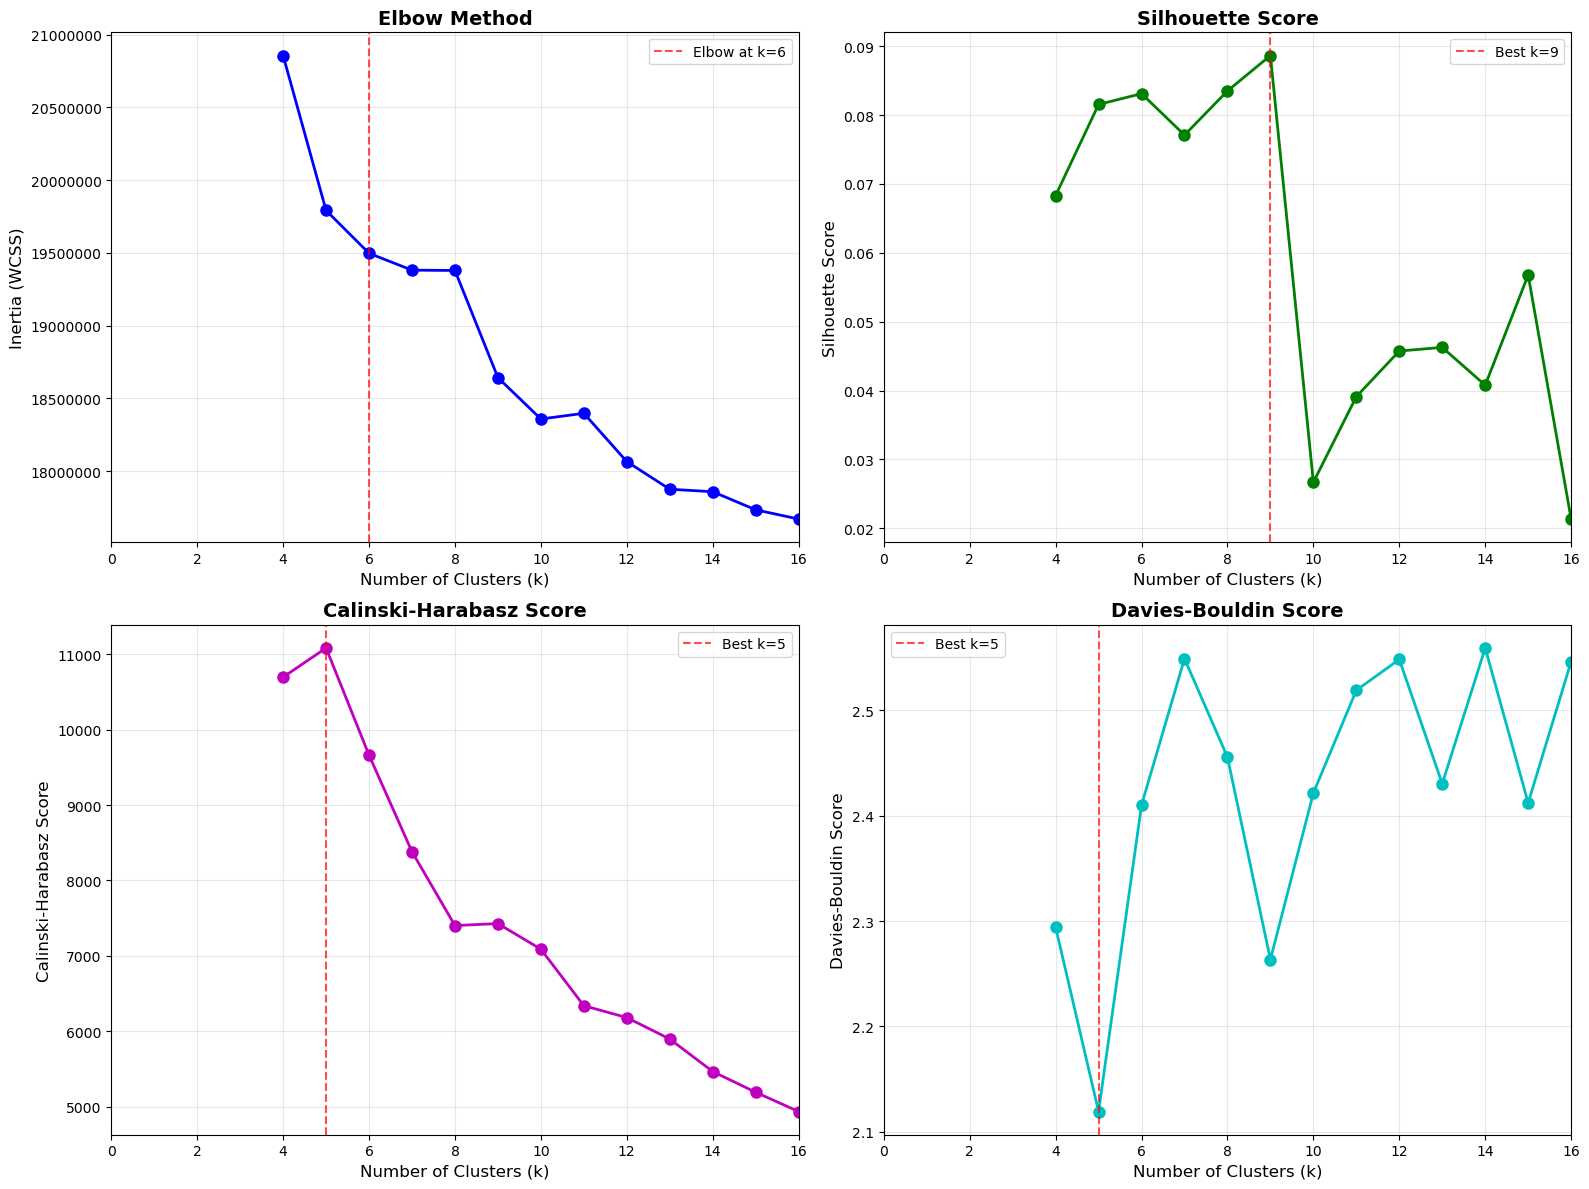

In [27]:
# ============================================================================
# Visualize All Metrics
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

x_ticks = np.arange(0, int(np.max(k_range)) + 2, 2)  # Build x-axis ticks starting at 0 with step size 2
for ax in axes.flat:  # Iterate through all subplots
    ax.set_xlim(0, int(np.max(k_range)))  # Set x-axis lower bound to 0 and upper bound to max k
    ax.set_xticks(x_ticks)  # Apply consistent x-axis ticks at 0, 2, 4, ...

# Elbow Method with automatic detection
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 0].set_ylabel('Inertia (WCSS)', fontsize=12)
axes[0, 0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
if elbow_k:
    axes[0, 0].axvline(x=elbow_k, color='r', linestyle='--', alpha=0.7, 
                       label=f'Elbow at k={elbow_k}')
axes[0, 0].legend()
axes[0, 0].ticklabel_format(style='plain', axis='y')

# Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12)
axes[0, 1].set_title('Silhouette Score', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
best_silhouette_k = k_range[np.argmax(silhouette_scores)]
axes[0, 1].axvline(x=best_silhouette_k, color='r', linestyle='--', alpha=0.7,
                   label=f'Best k={best_silhouette_k}')
axes[0, 1].legend()

# Calinski-Harabasz Score
axes[1, 0].plot(k_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12)
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=12)
axes[1, 0].set_title('Calinski-Harabasz Score', fontsize=14, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
best_calinski_k = k_range[np.argmax(calinski_scores)]
axes[1, 0].axvline(x=best_calinski_k, color='r', linestyle='--', alpha=0.7,
                   label=f'Best k={best_calinski_k}')
axes[1, 0].legend()
axes[1, 0].ticklabel_format(style='plain', axis='y')

# Plot Davies-Bouldin scores across k
axes[1, 1].plot(k_range, davies_scores, 'co-', linewidth=2, markersize=8) 
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12) 
axes[1, 1].set_ylabel('Davies-Bouldin Score', fontsize=12)
axes[1, 1].set_title('Davies-Bouldin Score', fontsize=14, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)  
best_davies_k = k_range[np.argmin(davies_scores)] 
axes[1, 1].axvline(x=best_davies_k, color='r', linestyle='--', alpha=0.7, label=f'Best k={best_davies_k}')  
axes[1, 1].legend()  

plt.tight_layout()
plt.show()

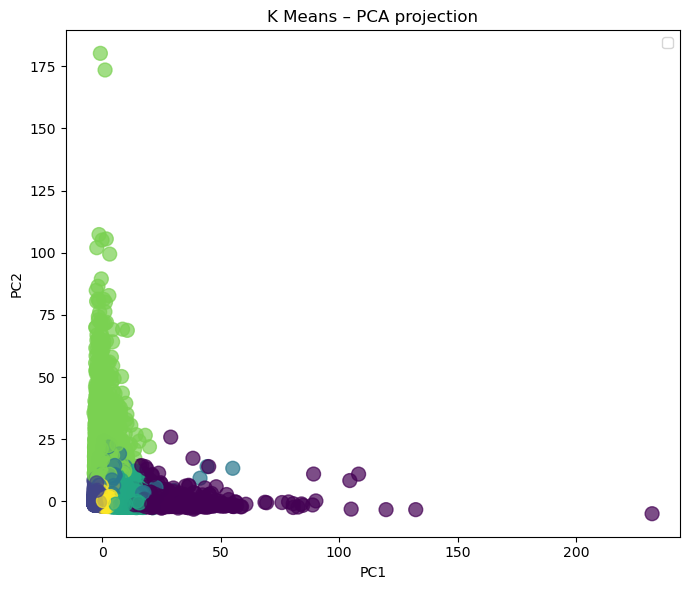

In [33]:
from sklearn.decomposition import PCA

k_values = np.array(list(k_range))  # Convert k_range to NumPy array
kmeans_best = KMeans(n_clusters=6, random_state=42, n_init=10)  # Initialize KMeans with best k
labels_best = kmeans_best.fit_predict(X_small)  # Fit KMeans and get cluster labels

# Project to 2D for visualization only
pca = PCA(n_components=2, random_state=42) 
X_2d = pca.fit_transform(X_small) 

plt.figure(figsize=(7, 6)) 
plt.scatter(X_2d[:, 0], X_2d[:, 1], 
            c=labels_best, 
            s=100, alpha=0.7
)  
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("K Means – PCA projection")
plt.legend()
plt.tight_layout()
plt.show()